In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
np.random.seed(42)

# Normal sales between 100 and 1000
normal_sales = np.random.normal(500, 120, 200)

# Add extreme outliers (very high and very low)
outliers = [50, 70, 2000, 2500, 3000]

sales_data = np.concatenate([normal_sales, outliers])

df = pd.DataFrame({'total_amount': sales_data})

print("Original Sales Data (First 10 Rows):")
print(df.head())
print("\n")

Original Sales Data (First 10 Rows):
   total_amount
0    559.605698
1    483.408284
2    577.722625
3    682.763583
4    471.901595




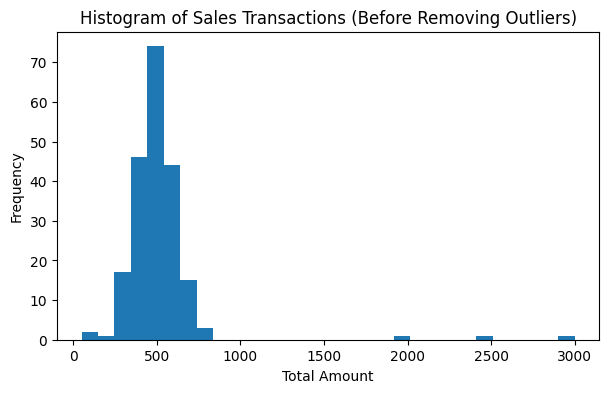

In [3]:
plt.figure(figsize=(7, 4))
plt.hist(df['total_amount'], bins=30)
plt.title("Histogram of Sales Transactions (Before Removing Outliers)")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

In [4]:
df['z_score'] = stats.zscore(df['total_amount'])

# Identify outliers using Z > 3 or Z < -3
outliers_df = df[(df['z_score'] > 3) | (df['z_score'] < -3)]

print("Identified Outliers:")
print(outliers_df)
print("\n")

Identified Outliers:
     total_amount   z_score
202        2000.0  5.418043
203        2500.0  7.248713
204        3000.0  9.079383




In [5]:
df_cleaned = df[(df['z_score'].abs() <= 3)]

print("Cleaned DataFrame Shape:")
print(df_cleaned.shape)
print("\n")


Cleaned DataFrame Shape:
(202, 2)




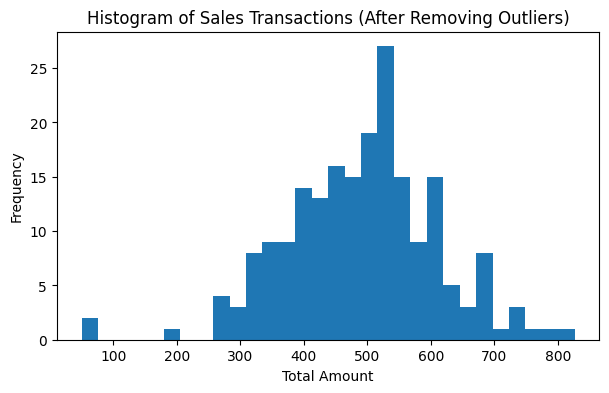

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(df_cleaned['total_amount'], bins=30)
plt.title("Histogram of Sales Transactions (After Removing Outliers)")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()